In [20]:
import pandas as pd
import numpy as np
import sympy as sp
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [36]:

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')


X['species'] = y.map(dict(zip(range(3), iris.target_names)))

print("First 5 rows of the dataset:")
print(X.head())


First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [37]:

X = X.drop('species', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)



Training set shape: (105, 4)
Test set shape: (45, 4)


In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")


Features scaled using StandardScaler.


In [39]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN model trained.")


KNN model trained.


In [40]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

print("Decision Tree model trained.")


Decision Tree model trained.


In [41]:
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_tree = accuracy_score(y_test, y_pred_tree)

print("KNN Accuracy:", acc_knn)
print("Decision Tree Accuracy:", acc_tree)


KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0


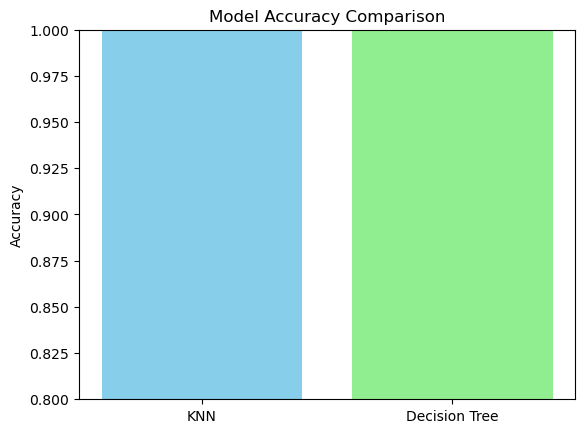

In [42]:
plt.bar(["KNN", "Decision Tree"], [acc_knn, acc_tree], color=["skyblue", "lightgreen"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.8, 1.0)
plt.show()


In [43]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("KNN Confusion Matrix:")
display(sp.Matrix(cm_knn))

print("\nDecision Tree Confusion Matrix:")
display(sp.Matrix(cm_tree))



KNN Confusion Matrix:


Matrix([
[19,  0,  0],
[ 0, 13,  0],
[ 0,  0, 13]])


Decision Tree Confusion Matrix:


Matrix([
[19,  0,  0],
[ 0, 13,  0],
[ 0,  0, 13]])

In [44]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))


KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

